# Time-Dependent Latent State Model for Disaster Tweet Behavior
### How do collective cognitive-emotional responses evolve after a disaster?

---

## Why are we doing this?

When a disaster strikes, people don't respond uniformly or statically.
There is a **pattern** that communities go through:

1. **Acute shock** (hours–days): People report casualties, send urgent requests, warn others
2. **Active mobilisation** (days–weeks): Rescue efforts, donations, infrastructure reports dominate
3. **Absorption** (weeks–month): Grief, sympathy, reflection
4. **Recovery discourse** (month+): Policy, retrospectives, reconstruction

The tweet class labels in this dataset are namely —*rescue/donation, sympathy, infrastructure damage,
caution, injured/dead* etc.

**Our goal**: Model the *proportion* of each tweet class as a function of time since the
disaster. If the model is correct, tweet proportions should shift predictably as the
collective state evolves. A Hidden Markov Model can capture the latent state
that drives those shifts.

---

## Formal Setup

Let:
- **t** = time phase since disaster (acute → active → absorbed → recovery)
- **X_t** = disaster antecedent intensity at time t (decays from 1 at t=0)
- **S_t** = latent cognitive-emotional state at time t (acute shock, mobilisation, recovery)
- **B_t** = observed vector of class-label proportions at time t

We model:
```
P(S_t | S_{t-1}, X_t)   ← how states transition, driven by fading disaster intensity
P(B_t | S_t)             ← what tweet proportions each state produces
```

This is an **Input-Output Hidden Markov Model (IOHMM)**.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.special import logsumexp
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 9})

LABEL_ORDER = [
    "rescue_volunteering_or_donation_effort",
    "other_relevant_information",
    "infrastructure_and_utility_damage",
    "sympathy_and_support",
    "injured_or_dead_people",
    "caution_and_advice",
    "displaced_people_and_evacuations",
    "not_humanitarian",
    "requests_or_urgent_needs",
    "missing_or_found_people",
]
SHORT = {
    "rescue_volunteering_or_donation_effort": "Rescue/Donation",
    "other_relevant_information":             "Other Info",
    "infrastructure_and_utility_damage":      "Infra Damage",
    "sympathy_and_support":                   "Sympathy",
    "injured_or_dead_people":                 "Injured/Dead",
    "caution_and_advice":                     "Caution",
    "displaced_people_and_evacuations":       "Displaced",
    "not_humanitarian":                       "Not Humanitarian",
    "requests_or_urgent_needs":               "Urgent Needs",
    "missing_or_found_people":                "Missing People",
}
N_LABELS = len(LABEL_ORDER)
PHASE_ORDER = ["acute", "active", "absorbed", "recovery"]
PHASE_DAYS  = {"acute": "0–3d", "active": "4–14d",
               "absorbed": "15–30d", "recovery": "31d+"}
COLORS = sns.color_palette("tab10", n_colors=N_LABELS)

print("Setup complete.")
print(f"Tracking {N_LABELS} class labels across {len(PHASE_ORDER)} time phases.")

Setup complete.
Tracking 10 class labels across 4 time phases.


## Data Loading & Time-Axis Engineering


We load the dataset and compute **days since disaster start** for every tweet.
This is the key: it converts absolute tweet timestamps into a *relative time axis*
that is comparable across all 11 disasters.

### Why time phases instead of raw days?
Tweet volume per day is uneven, some disasters have dense coverage on day 1,
sparse on day 10. Binning into four meaningful phases gives us stable proportion
estimates per phase and maps onto the psychological arc described above.

| Phase | Days | Psychological meaning |
|-------|------|----------------------|
| acute | 0–3 | Immediate shock, warnings, urgent requests |
| active | 4–14 | Organised response, peak media attention |
| absorbed | 15–30 | Grief sets in, reflective content |
| recovery | 31+ | Reconstruction, policy, retrospectives |

### The antecedent X_t
Disaster *intensity* decays exponentially from the start date:
```
X_t = exp(−λ · days_since_start),   λ = log(2)/7
```
This means intensity halves every 7 days — matching empirical news-cycle decay patterns.
At t=0 (disaster day): X=1.0. At day 7: X=0.5. At day 30: X≈0.05.

In [5]:
df = pd.read_csv("/content/crisisnlp_combined_dataset.csv")
df["tweet_time_utc"]      = pd.to_datetime(df["tweet_time_utc"],      utc=True, errors="coerce")
df["disaster_start_date"] = pd.to_datetime(df["disaster_start_date"], utc=True, errors="coerce")
.
df["days_since_start"] = (
    df["tweet_time_utc"] - df["disaster_start_date"]
).dt.total_seconds() / 86400.0

df = df[df["days_since_start"] >= 0].copy()

bins   = [-0.01, 3, 14, 30, 9999]
labels = ["acute", "active", "absorbed", "recovery"]
df["time_phase"] = pd.cut(df["days_since_start"], bins=bins, labels=labels)
df["time_phase"] = pd.Categorical(df["time_phase"], categories=PHASE_ORDER, ordered=True)

lam = np.log(2) / 7.0
df["disaster_intensity"] = np.exp(-lam * df["days_since_start"])

df["label_id"] = pd.Categorical(df["class_label"],
                                 categories=LABEL_ORDER).codes

print(f"Loaded {len(df):,} tweets across {df['disaster_name'].nunique()} disasters")
print(f"Date range: {df['tweet_time_utc'].min().date()} → {df['tweet_time_utc'].max().date()}")
print()
print("Tweets per time phase:")
print(df["time_phase"].value_counts().sort_index().rename(PHASE_DAYS))

Loaded 40,990 tweets across 11 disasters
Date range: 2016-04-17 → 2019-04-16

Tweets per time phase:
time_phase
0–3d       5601
4–14d     21953
15–30d    13036
31d+        400
Name: count, dtype: int64



## Computing Class-Label Proportions Over Time

This is the **central observation** of the whole analysis.
For each (disaster, time_phase) pair we compute:
```
proportion(label, phase, disaster) = count(label in phase) / total tweets in phase
```


### Why proportions, not raw counts?
Raw counts are confounded by tweet volume, disasters with more media coverage generate
more tweets overall, which would dominate any comparison. Proportions normalise this out
and give us the *relative salience* of each response type within each window.

In [6]:
prop = (
    df.groupby(["disaster_name", "time_phase", "class_label"], observed=True)
      .size()
      .reset_index(name="count")
)

phase_totals = (
    df.groupby(["disaster_name", "time_phase"], observed=True)
      .size()
      .reset_index(name="phase_total")
)

prop = prop.merge(phase_totals, on=["disaster_name", "time_phase"])
prop["proportion"] = prop["count"] / prop["phase_total"]
prop["short_label"] = prop["class_label"].map(SHORT)
prop["time_phase"]  = pd.Categorical(prop["time_phase"],
                                      categories=PHASE_ORDER, ordered=True)

agg = (
    prop.groupby(["time_phase", "class_label"], observed=True)["proportion"]
        .agg(["mean", "std", "count"])
        .reset_index()
)
agg["se"]          = agg["std"] / np.sqrt(agg["count"])
agg["short_label"] = agg["class_label"].map(SHORT)
agg["time_phase"]  = pd.Categorical(agg["time_phase"],
                                     categories=PHASE_ORDER, ordered=True)
agg = agg.sort_values(["class_label", "time_phase"])

print("Class-label proportion table (mean across disasters):")
pivot = agg.pivot_table(index="short_label", columns="time_phase",
                         values="mean", aggfunc="first")
print(pivot.round(3).to_string())

Class-label proportion table (mean across disasters):
time_phase        acute  active  absorbed  recovery
short_label                                        
Caution           0.081   0.053     0.037     0.044
Displaced         0.043   0.058     0.080     0.016
Infra Damage      0.078   0.116     0.131     0.061
Injured/Dead      0.180   0.104     0.072     0.044
Missing People      NaN   0.001     0.006     0.003
Not Humanitarian  0.044   0.044     0.039     0.029
Other Info        0.066   0.151     0.164     0.247
Rescue/Donation   0.246   0.342     0.417     0.528
Sympathy          0.294   0.145     0.062     0.060
Urgent Needs      0.031   0.035     0.040     0.016



## Proportion Trajectories Over Time



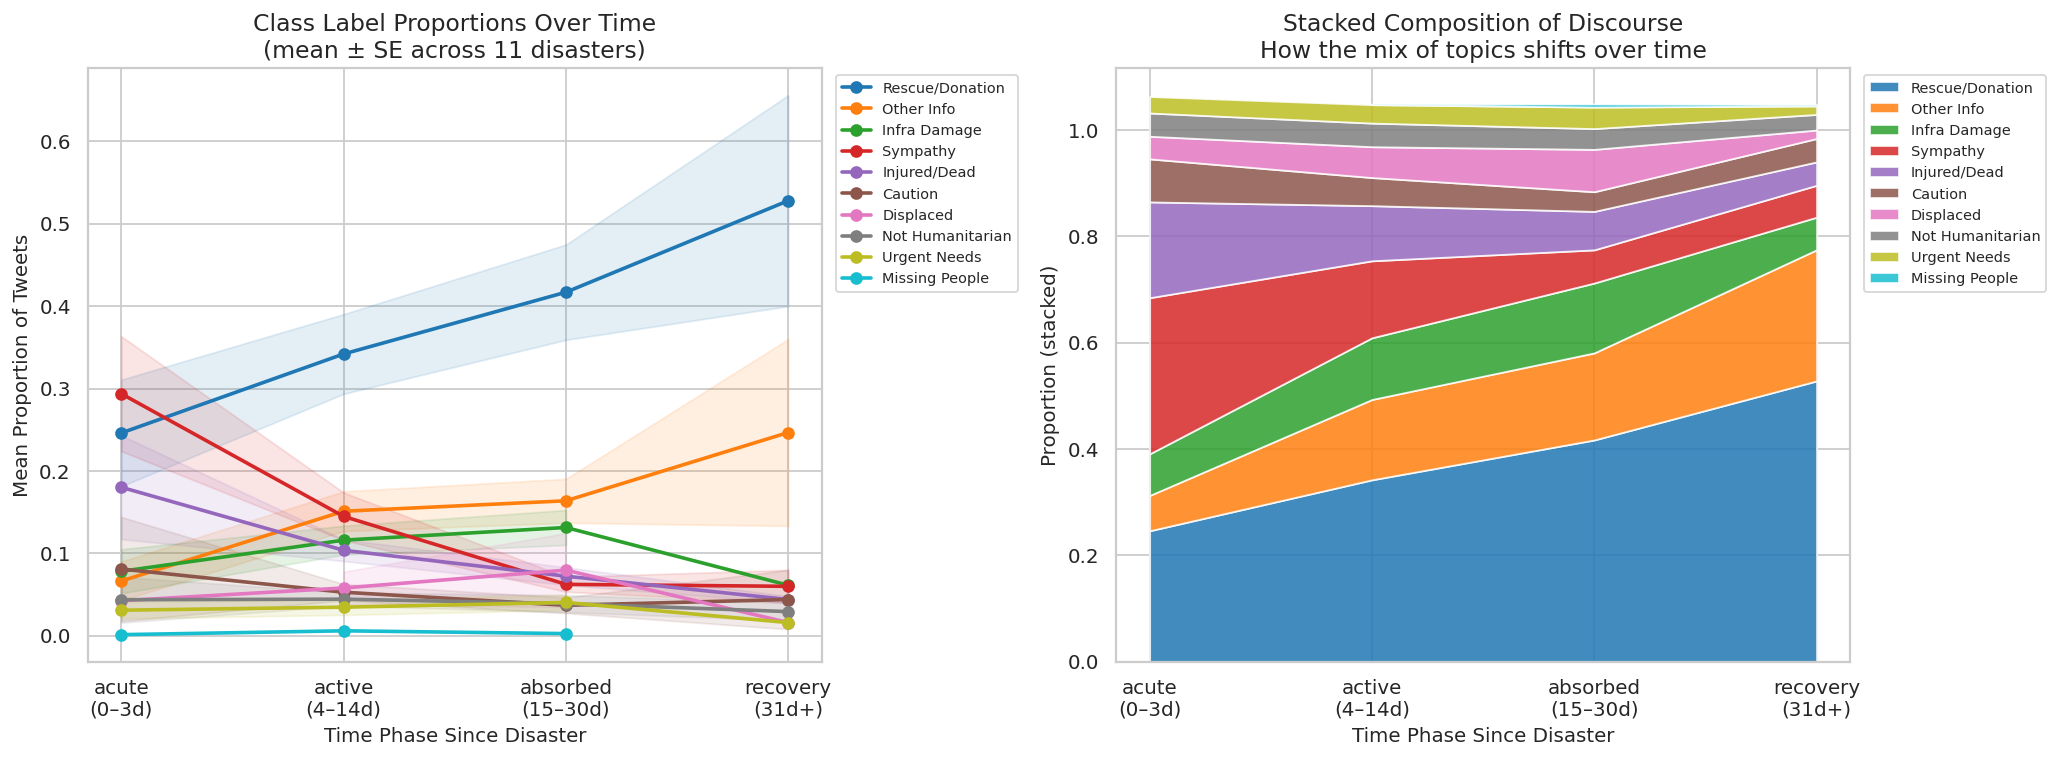

What to note: which labels peak early vs late? Which cross?


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, label in enumerate(LABEL_ORDER):
    sub = agg[agg["class_label"] == label].sort_values("time_phase")
    x   = np.arange(len(sub))
    ax.plot(x, sub["mean"], marker="o", linewidth=2,
            label=SHORT[label], color=COLORS[i])
    ax.fill_between(x,
                    sub["mean"] - sub["se"],
                    sub["mean"] + sub["se"],
                    alpha=0.12, color=COLORS[i])

ax.set_xticks(range(4))
ax.set_xticklabels([f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER])
ax.set_xlabel("Time Phase Since Disaster")
ax.set_ylabel("Mean Proportion of Tweets")
ax.set_title("Class Label Proportions Over Time\n(mean ± SE across 11 disasters)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

ax2 = axes[1]
pivot_area = agg.pivot_table(index="time_phase", columns="class_label",
                              values="mean", aggfunc="first")
pivot_area = pivot_area[LABEL_ORDER]   # consistent ordering

y = pivot_area.values.T     # (n_labels, 4)
x = np.arange(4)
ax2.stackplot(x, y, labels=[SHORT[l] for l in LABEL_ORDER],
              colors=COLORS, alpha=0.85)
ax2.set_xticks(range(4))
ax2.set_xticklabels([f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER])
ax2.set_xlabel("Time Phase Since Disaster")
ax2.set_ylabel("Proportion (stacked)")
ax2.set_title("Stacked Composition of Discourse\nHow the mix of topics shifts over time")
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("fig1_proportion_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-Disaster Heatmaps

Each disaster may have a *different* temporal signature depending on its type(hurricane vs earthquake vs wildfire), geography, and severity. We visualize the
proportion matrix for each disaster as a heatmap.

It reveals whether the time-dependent patterns are **universal** (same arc for all
disasters) or **disaster-specific** (antecedent-dependent).

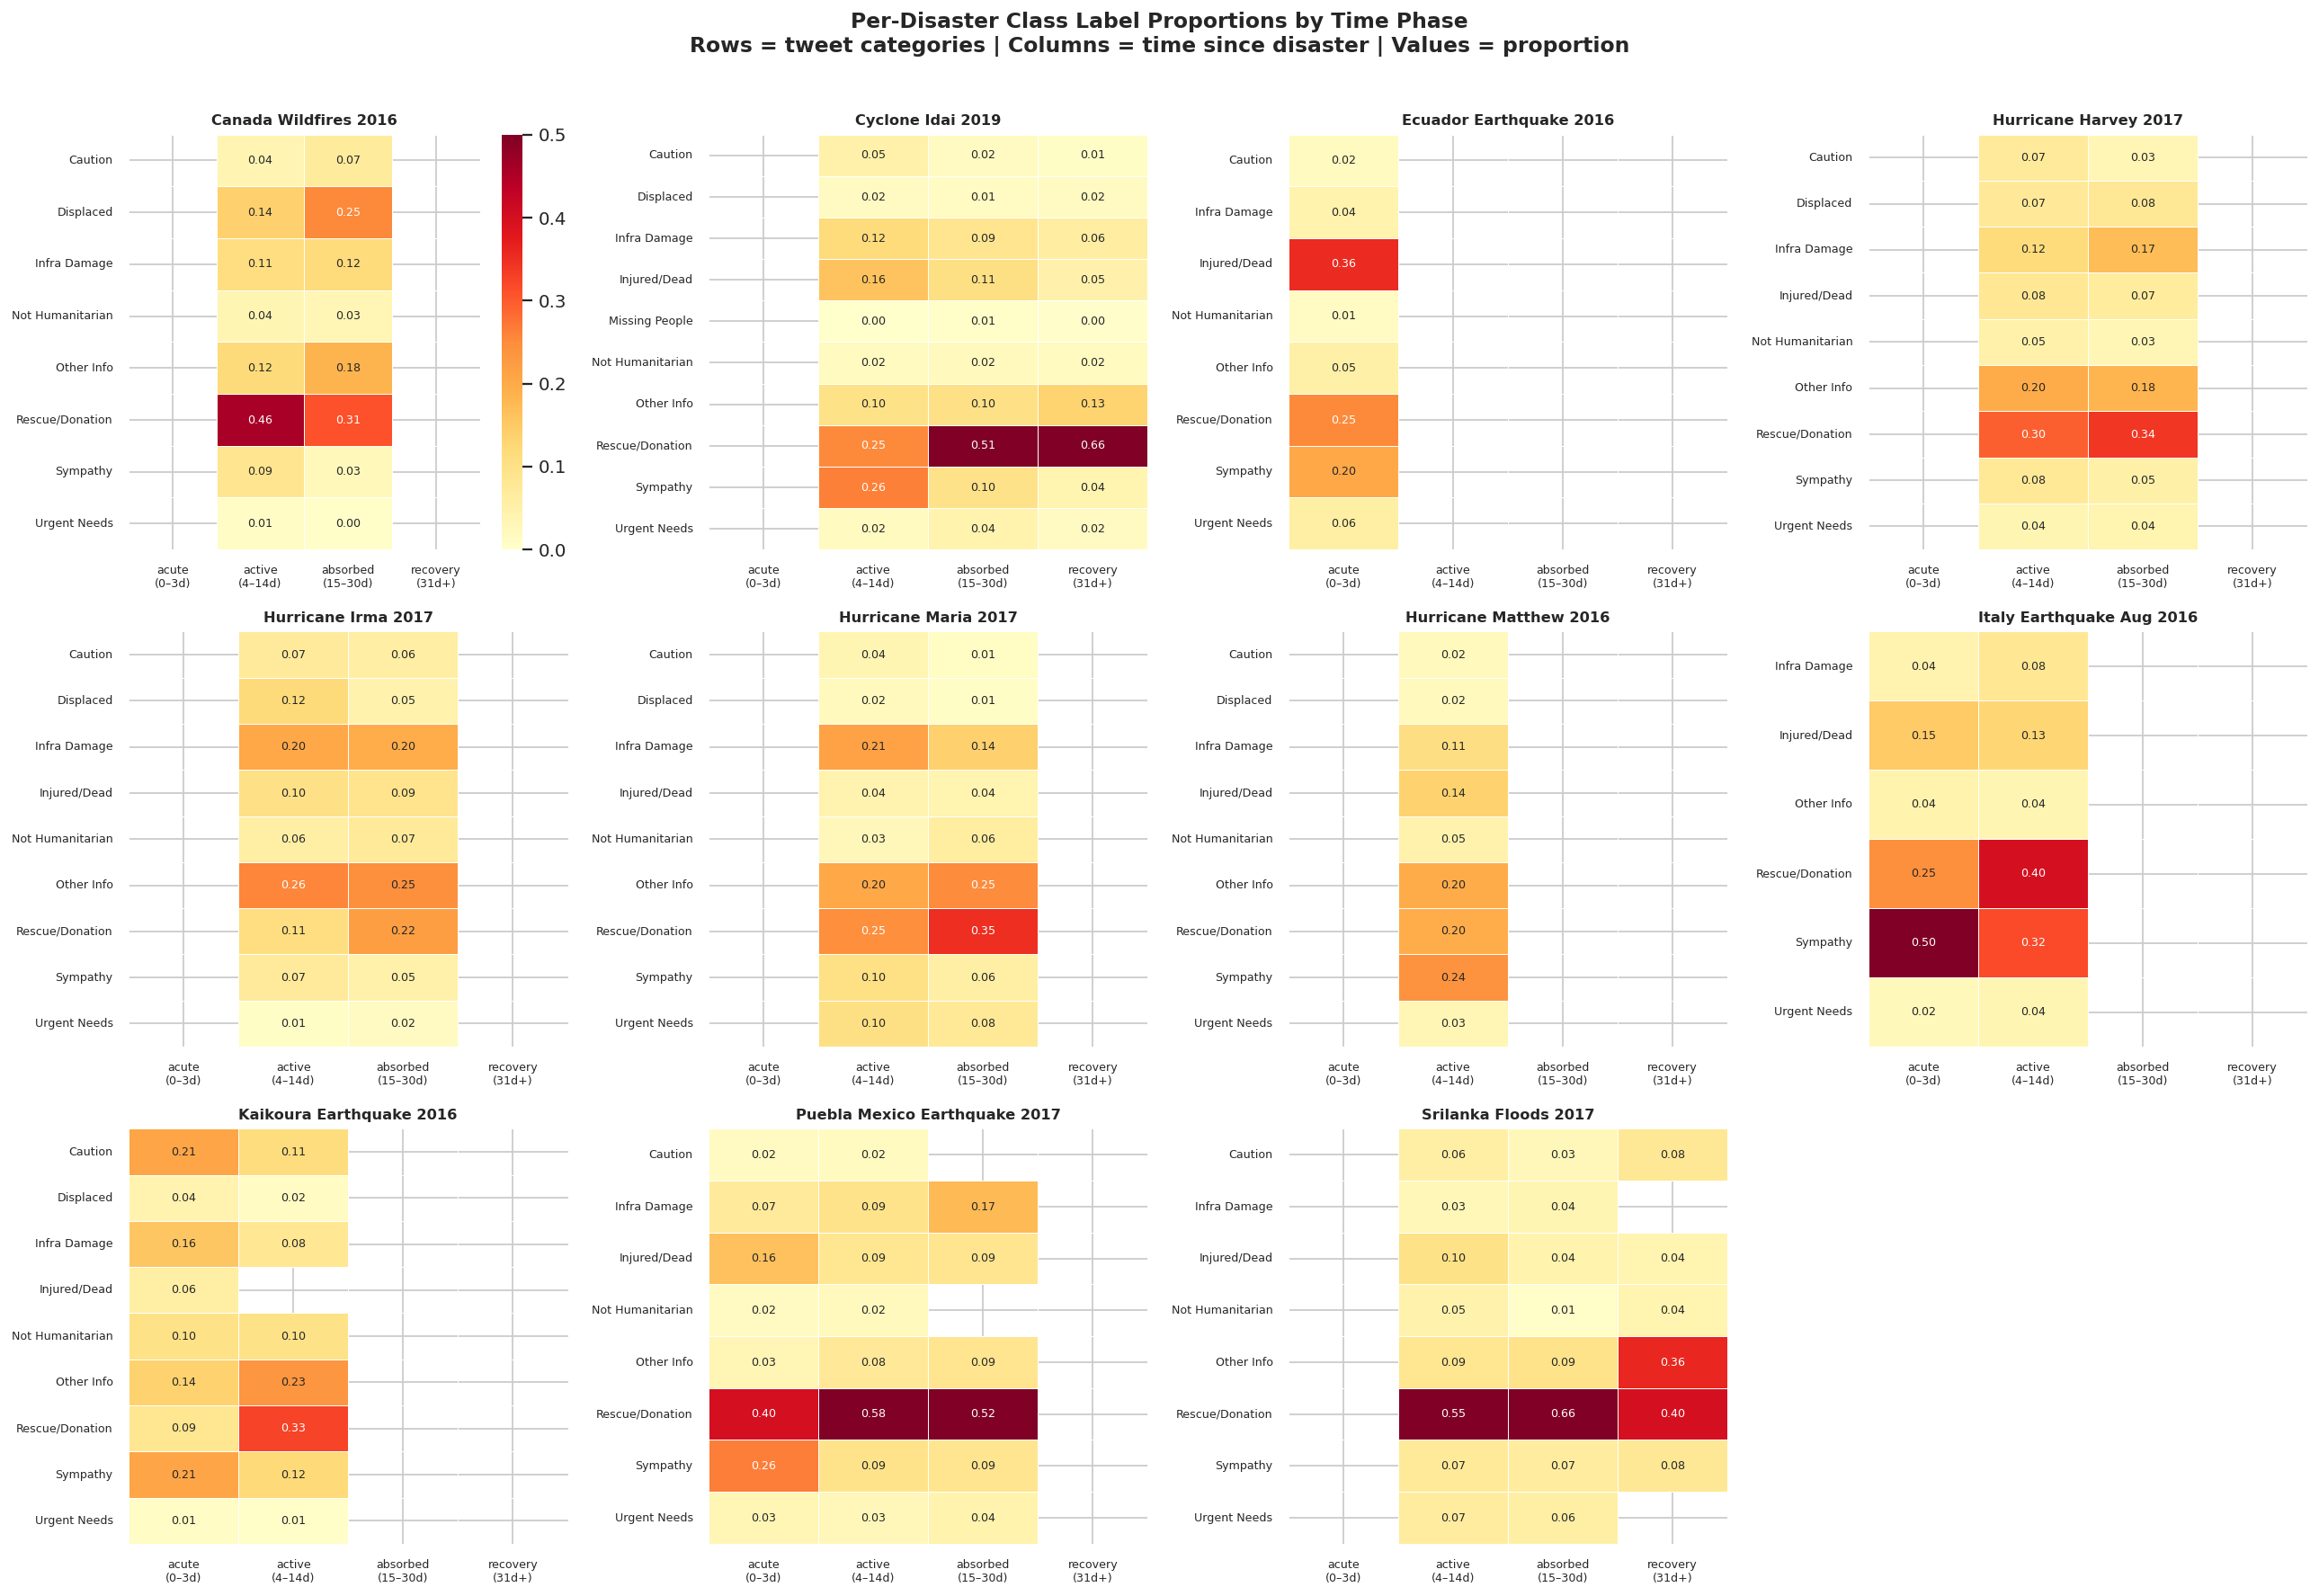

In [8]:
per_dis_pivots = {}
for dis, grp in prop.groupby("disaster_name"):
    piv = grp.pivot_table(index="short_label", columns="time_phase",
                           values="proportion", aggfunc="mean")
    piv = piv.reindex(columns=PHASE_ORDER)
    per_dis_pivots[dis] = piv

disasters_list = sorted(per_dis_pivots.keys())
n_dis = len(disasters_list)
ncols = 4
nrows = (n_dis + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4.5))
axes = axes.ravel()

for i, dis in enumerate(disasters_list):
    piv = per_dis_pivots[dis]
    for p in PHASE_ORDER:
        if p not in piv.columns:
            piv[p] = 0.0
    piv = piv[PHASE_ORDER]

    sns.heatmap(
        piv, ax=axes[i],
        cmap="YlOrRd", vmin=0, vmax=0.5,
        annot=True, fmt=".2f", annot_kws={"size": 7},
        linewidths=0.4, cbar=i == 0
    )
    title = dis.replace("_", " ").title()
    axes[i].set_title(title, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xticklabels(
        [f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER], fontsize=7, rotation=0)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Per-Disaster Class Label Proportions by Time Phase\n"
    "Rows = tweet categories | Columns = time since disaster | Values = proportion",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("fig2_per_disaster_heatmaps.png", dpi=130, bbox_inches="tight")
plt.show()

Across most disasters, early phases (acute/active) are dominated by rescue/donation, injured/dead, and infrastructure damage, which then decline over time. As days pass, discourse often shifts toward sympathy, other information, or reconstruction-related content, reflecting movement from immediate crisis response to reflection and longer-term adjustment.

However, the relative magnitudes differ by disaster type and context. Earthquakes show stronger early spikes in injured/dead and infrastructure damage (sudden-onset, high-casualty events), while hurricanes and floods show more sustained rescue/donation and infrastructure discussion (prolonged disruption, displacement, recovery logistics). Wildfires and floods sometimes show extended mobilisation phases, consistent with slower-moving hazards.


##  Antecedent Intensity Decay

Before fitting the model, we visualize the antecedent X_t — the disaster intensity
signal — to understand what the model is being driven by.

### Why exponential decay?
The empirical pattern of disaster-related media attention follows a **power-law or
exponential decay** . We use exponential
for tractability: `X_t = exp(−λt)`. The parameter λ controls how quickly the disaster
fades from collective attention. We set λ = log(2)/7, meaning *half-life of 7 days*.

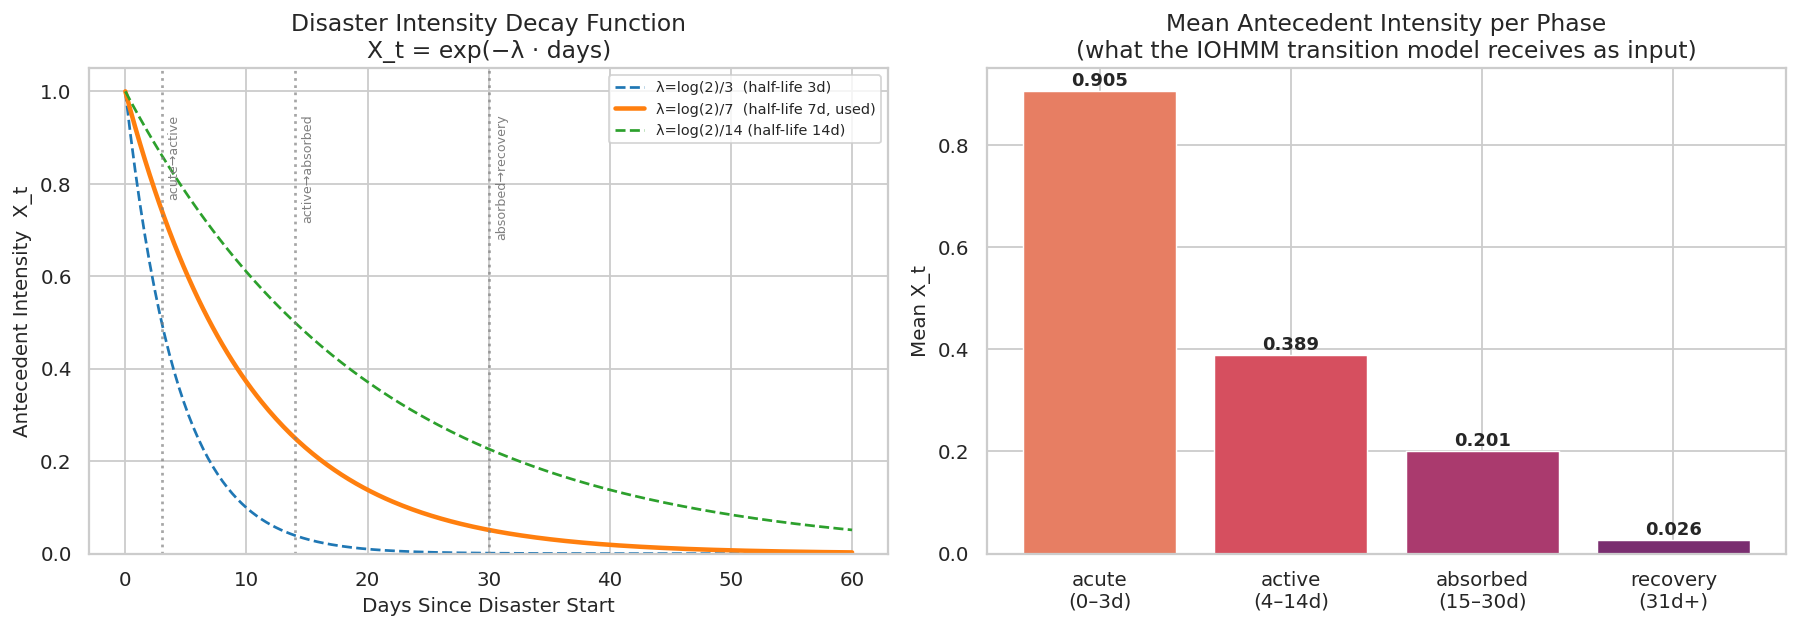

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days  = np.linspace(0, 60, 300)
lam_values = {"λ=log(2)/3  (half-life 3d)":  np.log(2)/3,
              "λ=log(2)/7  (half-life 7d, used)": np.log(2)/7,
              "λ=log(2)/14 (half-life 14d)": np.log(2)/14}

for label_str, lam_val in lam_values.items():
    linestyle = "-" if "used" in label_str else "--"
    linewidth = 2.5 if "used" in label_str else 1.5
    axes[0].plot(days, np.exp(-lam_val * days),
                 label=label_str, linewidth=linewidth, linestyle=linestyle)

for boundary, phase in zip([3, 14, 30], ["acute→active", "active→absorbed", "absorbed→recovery"]):
    axes[0].axvline(boundary, color="gray", linestyle=":", alpha=0.7)
    axes[0].text(boundary + 0.5, 0.95, phase, fontsize=7, color="gray", rotation=90, va="top")

axes[0].set_xlabel("Days Since Disaster Start")
axes[0].set_ylabel("Antecedent Intensity  X_t")
axes[0].set_title("Disaster Intensity Decay Function\nX_t = exp(−λ · days)")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.05)

## Building Sequences for the IOHMM

We convert the data into the format the Hidden Markov Model needs:
for each disaster, a **sequence of observation vectors** — one vector per time phase.

Each observation vector is the **proportion of each class label** in that phase.
So for disaster `D` at phase `t`:
```
obs[t] = [p(rescue), p(other_info), p(infra_damage), ..., p(missing_people)]
         (a 10-dimensional vector summing to 1)
```

The corresponding antecedent intensity `int[t]` is the mean X_t in that phase.


A proportion vector that is high on "caution" and "injured/dead" looks psychologically
very different from one that is high on "rescue/donation" and "sympathy".
The HMM's job is to discover which latent states produce which proportion patterns.

In [10]:
def build_sequences(df, prop_df):
    """
    For each disaster, build:
      - obs_seq:  list of T proportion vectors (T × 10)
      - int_seq:  list of T mean antecedent intensities
    Only include disasters with at least 2 phases of data.
    """
    sequences, intensities, disaster_names = [], [], []

    mean_intens = (
        df.groupby(["disaster_name", "time_phase"], observed=True)["disaster_intensity"]
          .mean()
          .reset_index()
    )

    for dis in sorted(df["disaster_name"].unique()):
        seq, intv = [], []
        for phase in PHASE_ORDER:
            sub_prop = prop_df[(prop_df["disaster_name"] == dis) &
                               (prop_df["time_phase"] == phase)]
            sub_int  = mean_intens[(mean_intens["disaster_name"] == dis) &
                                   (mean_intens["time_phase"] == phase)]
            if len(sub_prop) == 0 or len(sub_int) == 0:
                continue

            obs_vec = np.zeros(N_LABELS)
            for _, row in sub_prop.iterrows():
                if row["class_label"] in LABEL_ORDER:
                    idx = LABEL_ORDER.index(row["class_label"])
                    obs_vec[idx] = row["proportion"]
            obs_vec /= (obs_vec.sum() + 1e-9)

            seq.append(obs_vec)
            intv.append(sub_int["disaster_intensity"].values[0])

        if len(seq) >= 2:
            sequences.append(np.array(seq))
            intensities.append(np.array(intv))
            disaster_names.append(dis)

    return sequences, intensities, disaster_names

sequences, intensities, disaster_names = build_sequences(df, prop)

print(f"Usable disasters: {len(sequences)}")
print()
for dis, seq, intv in zip(disaster_names, sequences, intensities):
    print(f"  {dis:<42s}  T={len(seq)}  intensity range [{intv.min():.3f}, {intv.max():.3f}]")

Usable disasters: 9

  canada_wildfires_2016                       T=2  intensity range [0.168, 0.463]
  cyclone_idai_2019                           T=3  intensity range [0.026, 0.285]
  hurricane_harvey_2017                       T=2  intensity range [0.233, 0.316]
  hurricane_irma_2017                         T=2  intensity range [0.208, 0.375]
  hurricane_maria_2017                        T=2  intensity range [0.225, 0.411]
  italy_earthquake_aug_2016                   T=2  intensity range [0.683, 0.887]
  kaikoura_earthquake_2016                    T=2  intensity range [0.485, 0.933]
  puebla_mexico_earthquake_2017               T=3  intensity range [0.209, 0.888]
  srilanka_floods_2017                        T=3  intensity range [0.035, 0.414]


##  The IOHMM: Theory & Implementation

### Why a Hidden Markov Model?
The class label proportions we observe are *noisy* and *indirect* traces of the
underlying cognitive-emotional state of the collective. The HMM formalizes this:

```
[S_0] ──X_1──▶ [S_1] ──X_2──▶ [S_2] ──X_3──▶ [S_3]
   ↓                ↓                ↓                ↓
 B_0             B_1             B_2             B_3
(proportions)  (proportions)  (proportions)  (proportions)
```

### Why *Input-Output* HMM?
Standard HMMs assume transitions are stationary, the probability of moving from
state i to state j is the same at every timestep. But we *know* that disaster
intensity is changing (decaying). An IOHMM lets the transition matrix be a
**function of X_t**:

```
A(X_t)[i,j] = P(S_t = j | S_{t-1} = i, X_t)
             = softmax( W[i,j] + v[i,j] · X_t )
```

Here W [i,j] is the baseline tendency to transition from i→j, and v [i,j] is
*how much the disaster intensity amplifies or suppresses that transition*.

A **positive v[i,j]** means: when the disaster is intense, transitions from i→j
are more likely (e.g., intensity keeps people in "acute" state).
A **negative v[i,j]** means: when intensity is high, this transition is suppressed.

### Emission model
Each state k emits a proportion vector:
```
P(B_t | S_t = k) ∝ exp(log_B[k])
```
We use cross-entropy between the observed proportion vector and the state's
emission to compute the log-likelihood.


In [11]:
class IOHMM:
    """
    Input-Output Hidden Markov Model.

    Latent states: K (collective cognitive-emotional phases)
    Observations:  D-dimensional proportion vectors (D = 10 tweet classes)
    Input:         X_t = disaster intensity at time t

    Transition: A(X_t)[i,j] = softmax_j( W[i,j] + v[i,j]*X_t )
    Emission:   log P(B_t|S_t=k) = sum_d obs[d] * log_B_normalized[k,d]
    """

    def __init__(self, n_states=3, n_obs=10, random_state=42):
        self.K   = n_states
        self.D   = n_obs
        self.rng = np.random.default_rng(random_state)


    def _n_params(self):
        return self.K + self.K*self.K + self.K*self.K + self.K*self.D

    def _unpack(self, params):
        K, D = self.K, self.D
        i = 0
        log_pi = params[i:i+K];              i += K
        W_A    = params[i:i+K*K].reshape(K,K); i += K*K
        v_A    = params[i:i+K*K].reshape(K,K); i += K*K
        log_B  = params[i:i+K*D].reshape(K,D)
        return log_pi, W_A, v_A, log_B

    def _init_params(self):
        K, D = self.K, self.D
        log_pi = np.zeros(K)
        W_A    = self.rng.normal(0, 0.3, (K, K))
        v_A    = self.rng.normal(0, 0.3, (K, K))
        log_B  = self.rng.normal(0, 0.3, (K, D))
        return np.concatenate([log_pi, W_A.ravel(), v_A.ravel(), log_B.ravel()])
    def _transition(self, W_A, v_A, x_t):
        logits = W_A + v_A * x_t
        logits -= logits.max(axis=1, keepdims=True)
        A = np.exp(logits)
        A /= A.sum(axis=1, keepdims=True)
        return A

    def _log_emission(self, log_B, obs_vec):
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        return log_B_norm @ obs_vec
    def _forward(self, params, obs_seq, int_seq):
        log_pi, W_A, v_A, log_B = self._unpack(params)
        T, K = len(obs_seq), self.K
        alpha = np.full((T, K), -np.inf)

        pi       = log_pi - logsumexp(log_pi)
        alpha[0] = pi + self._log_emission(log_B, obs_seq[0])

        for t in range(1, T):
            A     = self._transition(W_A, v_A, int_seq[t])
            log_A = np.log(A + 1e-12)
            log_e = self._log_emission(log_B, obs_seq[t])
            for j in range(K):
                alpha[t, j] = logsumexp(alpha[t-1] + log_A[:, j]) + log_e[j]

        return logsumexp(alpha[-1]), alpha

    def _neg_ll(self, params, sequences, intensities):
        total = 0.0
        for obs_seq, int_seq in zip(sequences, intensities):
            ll, _ = self._forward(params, obs_seq, int_seq)
            if not np.isfinite(ll):
                return 1e10
            total += ll
        return -total

    def fit(self, sequences, intensities, n_restarts=5, verbose=True):
        best_ll, best_params = np.inf, None
        for r in range(n_restarts):
            p0 = self._init_params()
            res = minimize(self._neg_ll, p0,
                           args=(sequences, intensities),
                           method="L-BFGS-B",
                           options={"maxiter": 600, "ftol": 1e-9})
            if res.fun < best_ll:
                best_ll, best_params = res.fun, res.x
                if verbose:
                    print(f"  Restart {r+1}/{n_restarts}: log-lik = {-res.fun:.3f}")
        self.params_  = best_params
        self.log_lik_ = -best_ll
        self._cache_matrices()
        return self

    def _cache_matrices(self):
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        self.pi_  = np.exp(log_pi - logsumexp(log_pi))
        self.W_A_ = W_A
        self.v_A_ = v_A
        log_B_norm = log_B - logsumexp(log_B, axis=1, keepdims=True)
        self.B_   = np.exp(log_B_norm)    # (K, D) — emission probabilities
    def decode(self, obs_seq, int_seq):
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        T, K = len(obs_seq), self.K
        V    = np.full((T, K), -np.inf)
        bp   = np.zeros((T, K), dtype=int)
        pi   = log_pi - logsumexp(log_pi)
        V[0] = pi + self._log_emission(log_B, obs_seq[0])
        for t in range(1, T):
            A     = self._transition(W_A, v_A, int_seq[t])
            log_A = np.log(A + 1e-12)
            log_e = self._log_emission(log_B, obs_seq[t])
            for j in range(K):
                scores = V[t-1] + log_A[:, j]
                bp[t,j] = np.argmax(scores)
                V[t,j]  = scores[bp[t,j]] + log_e[j]
        path = [int(np.argmax(V[-1]))]
        for t in range(T-1, 0, -1):
            path.append(bp[t, path[-1]])
        return list(reversed(path))

    def simulate(self, int_seq, n_trials=1):
        log_pi, W_A, v_A, log_B = self._unpack(self.params_)
        pi = np.exp(log_pi - logsumexp(log_pi))
        B  = self.B_
        all_states, all_obs = [], []
        for _ in range(n_trials):
            T      = len(int_seq)
            states = np.zeros(T, dtype=int)
            obs    = np.zeros((T, self.D))
            states[0] = np.random.choice(self.K, p=pi)
            obs[0]    = np.random.dirichlet(B[states[0]] * 10 + 1e-3)
            for t in range(1, T):
                A         = self._transition(W_A, v_A, int_seq[t])
                states[t] = np.random.choice(self.K, p=A[states[t-1]])
                obs[t]    = np.random.dirichlet(B[states[t]] * 10 + 1e-3)
            all_states.append(states); all_obs.append(obs)
        return all_states, all_obs

    def aic(self):    return 2*self._n_params() - 2*self.log_lik_
    def bic(self, n): return self._n_params()*np.log(n) - 2*self.log_lik_

print("IOHMM class defined successfully.")
print(f"Number of parameters for K=3 states: {IOHMM(3,10)._n_params()}")
print(f"  Breakdown: {3} (pi) + {3*3} (W_A) + {3*3} (v_A) + {3*10} (B) = {3+9+9+30}")

IOHMM class defined successfully.
Number of parameters for K=3 states: 51
  Breakdown: 3 (pi) + 9 (W_A) + 9 (v_A) + 30 (B) = 51


##  Fit the Combined IOHMM


We fit a single IOHMM to *all 11 disasters jointly*. This means the model learns
latent states that are **universal across disaster types** : hurricane, earthquake,
wildfire, cyclone using the class label proportion trajectories as evidence.

Fitting jointly pools information across disasters. Each disaster gives us at most
4 time points — far too few to estimate an HMM from a single sequence. But 11
disasters × 4 phases = up to 44 observations, enough to estimate the model.

We try K=2, 3, and 4. We select the best by **AIC** (penalizes complexity lightly)
and **BIC** (penalizes complexity more strongly).

In [12]:
print("Fitting IOHMM for K = 2, 3, 4 states...")
print("(Multiple restarts per K to avoid local optima)\n")

n_obs_total = sum(len(s) for s in sequences)
fit_results = {}

for K in [2, 3, 4]:
    print(f"── K = {K} ──")
    model = IOHMM(n_states=K, n_obs=N_LABELS, random_state=42)
    model.fit(sequences, intensities, n_restarts=8, verbose=True)
    fit_results[K] = {
        "model":   model,
        "log_lik": model.log_lik_,
        "AIC":     model.aic(),
        "BIC":     model.bic(n_obs_total),
        "n_params": model._n_params(),
    }
    print(f"   → log-lik={model.log_lik_:.2f}  AIC={model.aic():.2f}  BIC={model.bic(n_obs_total):.2f}\n")

print("\n{:<6} {:>10} {:>10} {:>10} {:>10}".format("K", "log-lik", "AIC", "BIC", "#params"))
print("-"*50)
for K, r in fit_results.items():
    print("{:<6} {:>10.2f} {:>10.2f} {:>10.2f} {:>10}".format(
        K, r["log_lik"], r["AIC"], r["BIC"], r["n_params"]))

# Select best K by BIC (more conservative)
best_K = min(fit_results, key=lambda k: fit_results[k]["BIC"])
model  = fit_results[best_K]["model"]
print(f"\nSelected K = {best_K} by BIC.")

Fitting IOHMM for K = 2, 3, 4 states...
(Multiple restarts per K to avoid local optima)

── K = 2 ──
  Restart 1/8: log-lik = -38.718
  Restart 2/8: log-lik = -38.718
   → log-lik=-38.72  AIC=137.44  BIC=168.77

── K = 3 ──
  Restart 1/8: log-lik = -38.718
  Restart 2/8: log-lik = -38.718
  Restart 3/8: log-lik = -38.553
   → log-lik=-38.55  AIC=179.11  BIC=232.38

── K = 4 ──
  Restart 1/8: log-lik = -38.553
  Restart 3/8: log-lik = -38.455
  Restart 8/8: log-lik = -38.322
   → log-lik=-38.32  AIC=228.64  BIC=308.03


K         log-lik        AIC        BIC    #params
--------------------------------------------------
2          -38.72     137.44     168.77         30
3          -38.55     179.11     232.38         51
4          -38.32     228.64     308.03         76

Selected K = 2 by BIC.


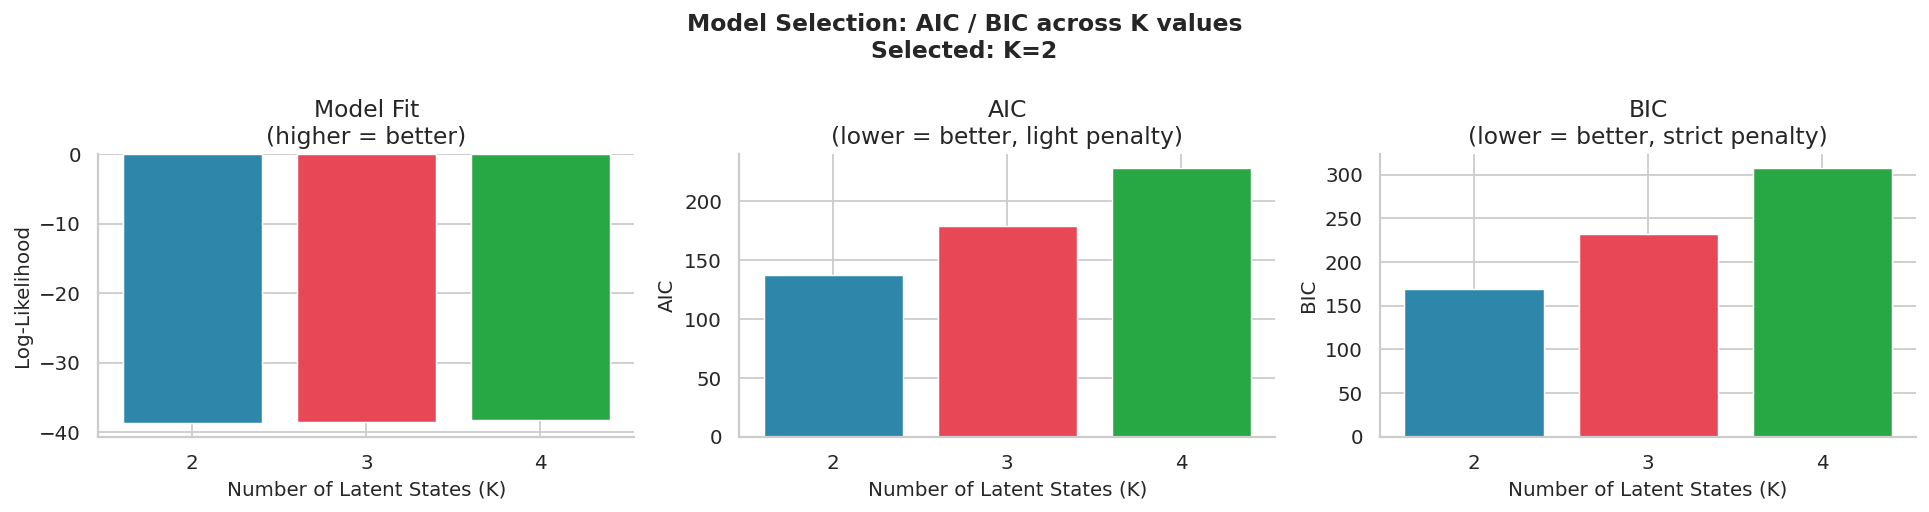

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

Ks      = list(fit_results.keys())
ll_vals = [fit_results[k]["log_lik"] for k in Ks]
aic_vals= [fit_results[k]["AIC"]     for k in Ks]
bic_vals= [fit_results[k]["BIC"]     for k in Ks]

palette = {"2": "#2E86AB", "3": "#E84855", "4": "#28A745"}
colors_bar = [palette[str(k)] for k in Ks]

axes[0].bar(Ks, ll_vals, color=colors_bar, edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Number of Latent States (K)")
axes[0].set_ylabel("Log-Likelihood")
axes[0].set_title("Model Fit\n(higher = better)")
axes[0].set_xticks(Ks)

axes[1].bar(Ks, aic_vals, color=colors_bar, edgecolor="white", linewidth=0.8)
axes[1].set_xlabel("Number of Latent States (K)")
axes[1].set_ylabel("AIC")
axes[1].set_title("AIC\n(lower = better, light penalty)")
axes[1].set_xticks(Ks)

axes[2].bar(Ks, bic_vals, color=colors_bar, edgecolor="white", linewidth=0.8)
axes[2].set_xlabel("Number of Latent States (K)")
axes[2].set_ylabel("BIC")
axes[2].set_title("BIC\n(lower = better, strict penalty)")
axes[2].set_xticks(Ks)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"Model Selection: AIC / BIC across K values\nSelected: K={best_K}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_model_selection.png", dpi=150, bbox_inches="tight")
plt.show()


## Emission Matrix (What Each State Tweets About)

The emission matrix B[k, d] = P(class d | state k) tells us **what each latent
state says** in terms of tweet categories. This is the key to psychological interpretation.

A state that's high on "Injured/Dead" and "Urgent Needs" is clearly an **acute crisis state**.
A state high on "Sympathy" and "Other Info" is a **reflective/recovery state**.

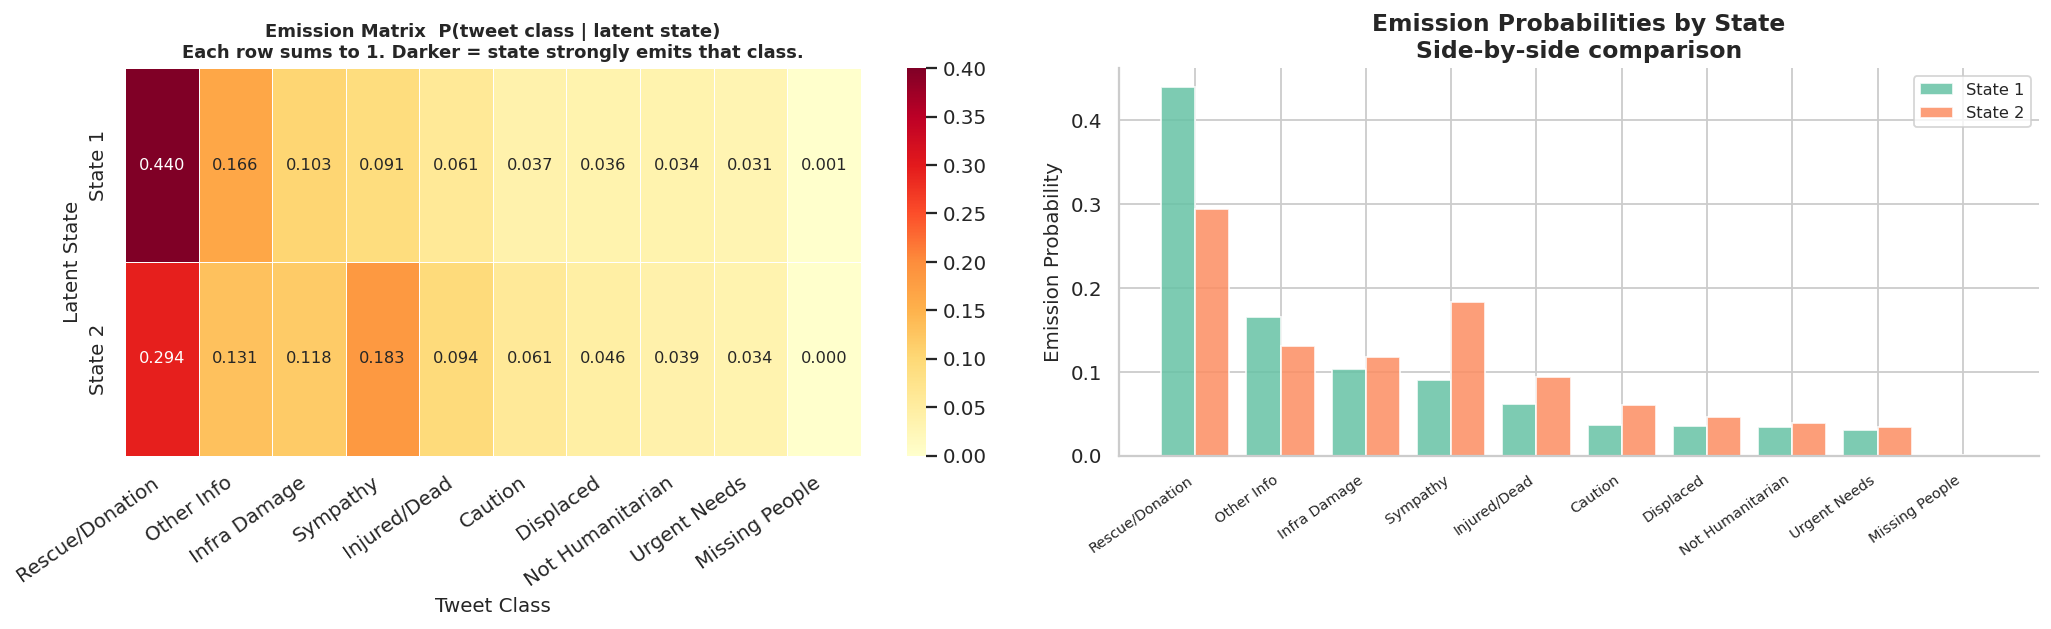

In [14]:
short_labels = [SHORT[l] for l in LABEL_ORDER]
state_names  = [f"State {k+1}" for k in range(best_K)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
B_df = pd.DataFrame(model.B_, columns=short_labels, index=state_names)
sns.heatmap(B_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0], vmin=0, vmax=0.4,
            annot_kws={"size": 9})
axes[0].set_title("Emission Matrix  P(tweet class | latent state)\n"
                   "Each row sums to 1. Darker = state strongly emits that class.",
                   fontsize=10, fontweight="bold")
axes[0].set_xlabel("Tweet Class")
axes[0].set_ylabel("Latent State")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")

state_colors = sns.color_palette("Set2", n_colors=best_K)
x = np.arange(N_LABELS)
bar_width = 0.8 / best_K
for k in range(best_K):
    offset = (k - best_K/2 + 0.5) * bar_width
    axes[1].bar(x + offset, model.B_[k], width=bar_width,
                label=f"State {k+1}", color=state_colors[k], alpha=0.85, edgecolor="white")

axes[1].set_xticks(x)
axes[1].set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Emission Probability")
axes[1].set_title("Emission Probabilities by State\nSide-by-side comparison", fontweight="bold")
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig5_emission_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Viterbi Decoded State Trajectories

The **Viterbi algorithm** finds the most likely sequence of hidden states that
could have produced each disaster's observed proportion trajectory. This is
decoding: going from observations back to latent states.

### Why Viterbi and not just argmax per timestep?
Viterbi is globally optimal — it finds the path that maximizes the joint probability
of the entire sequence, respecting the Markov structure. Simply taking the
highest-probability state at each step independently ignores the transition constraints
and often produces incoherent jumps.

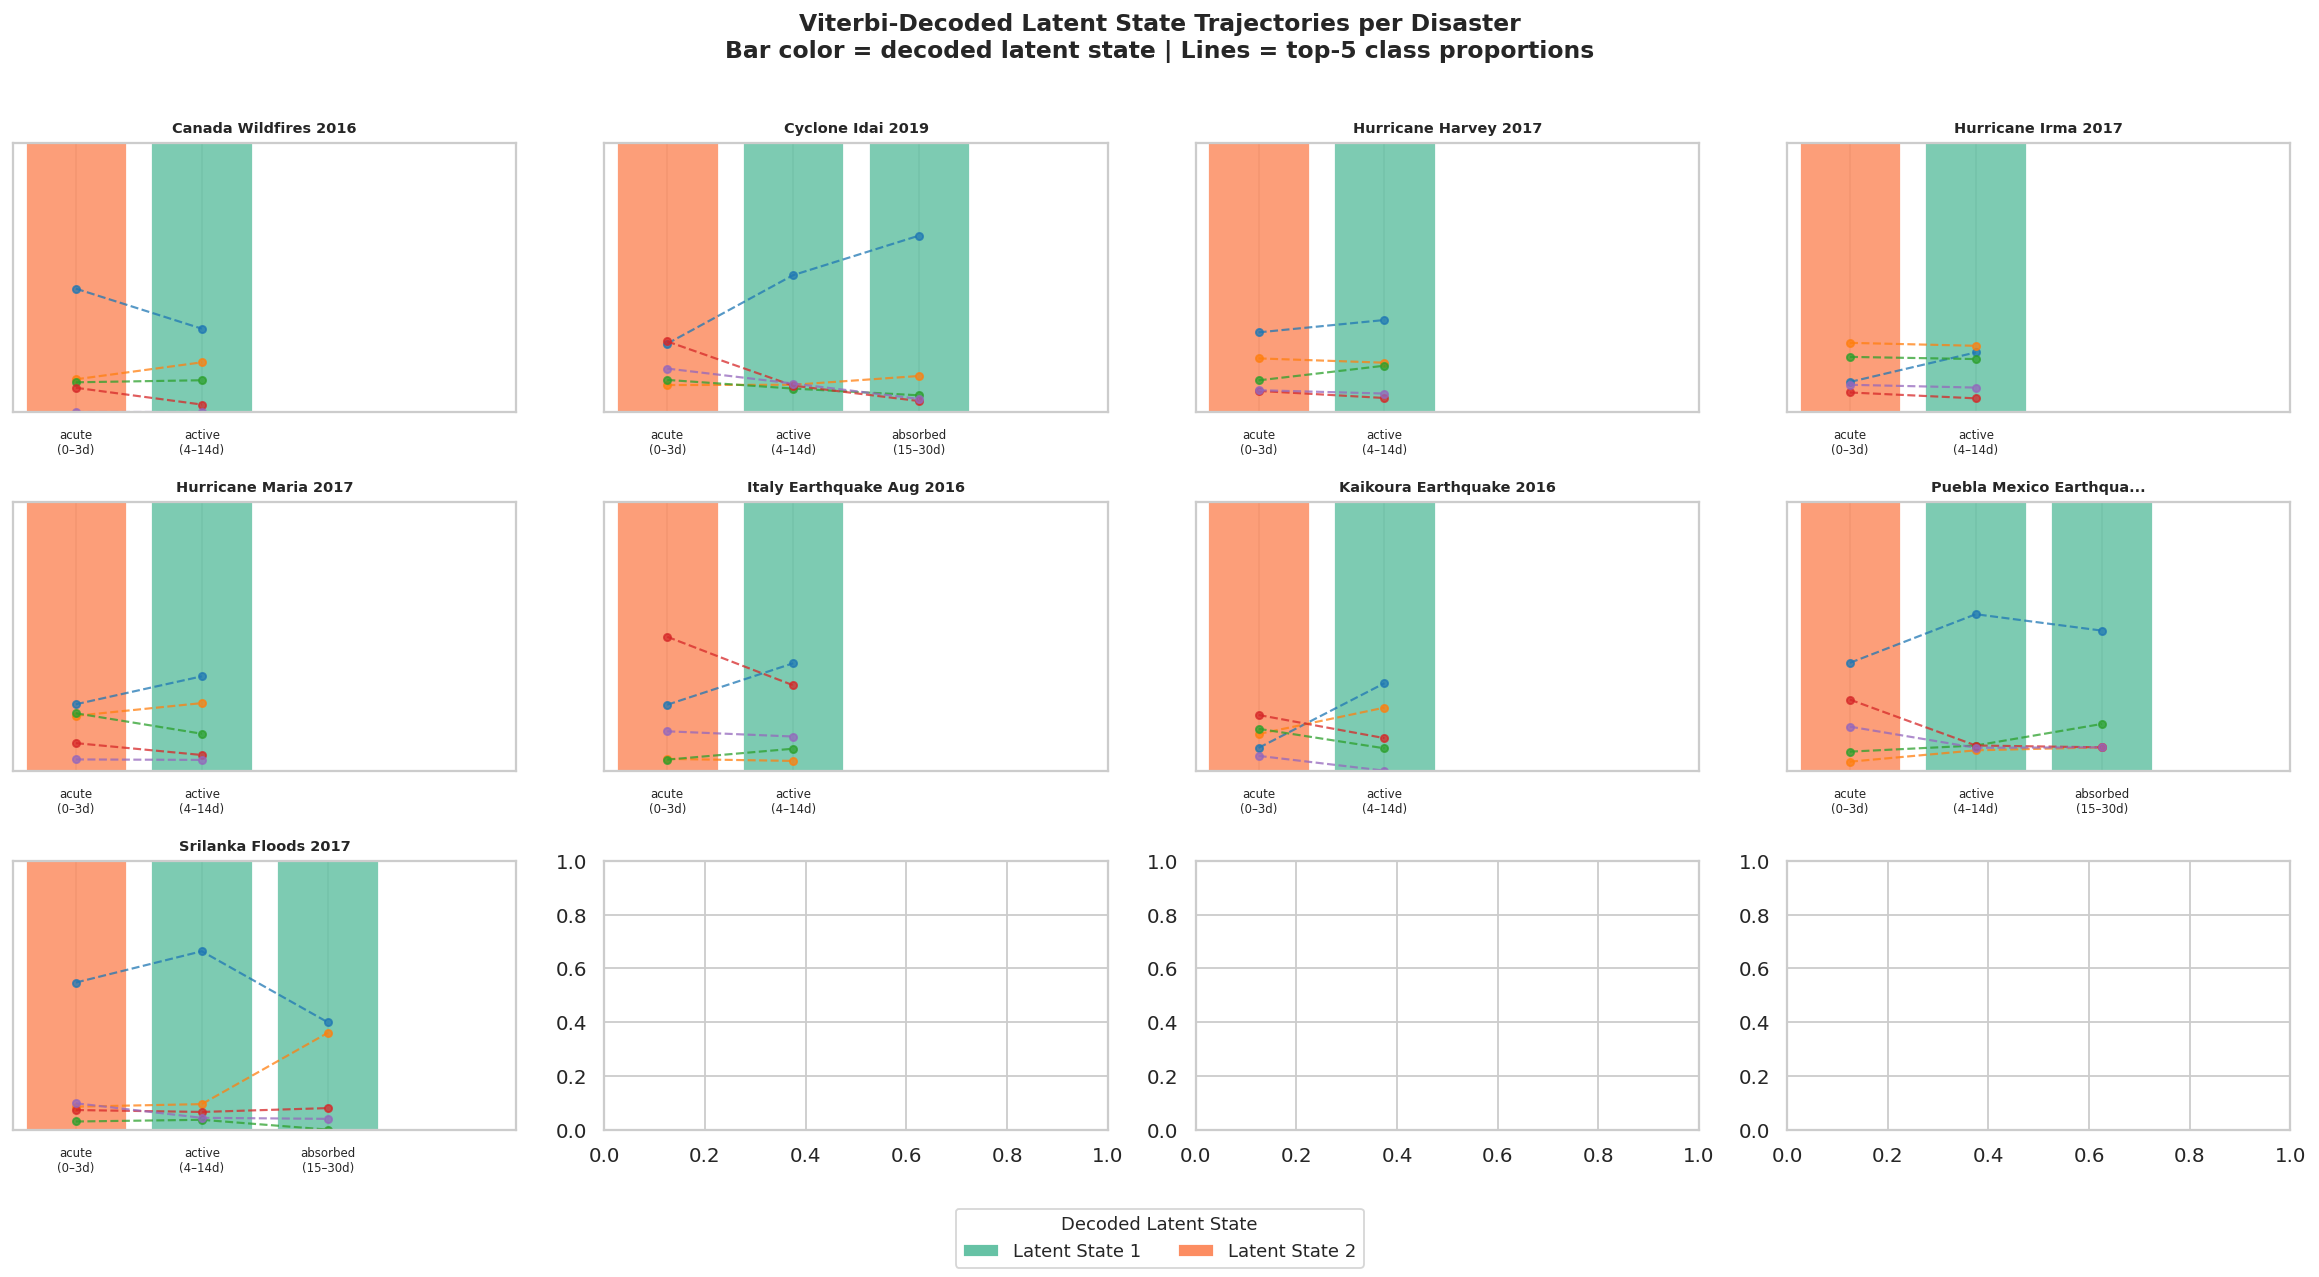

In [16]:
phase_xlabels = [f"{p}\n({PHASE_DAYS[p]})" for p in PHASE_ORDER]
state_colors  = sns.color_palette("Set2", n_colors=best_K)

n_dis   = len(disaster_names)
ncols   = 4
nrows   = (n_dis + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes    = axes.ravel()

all_paths = []
for i, (dis, seq, intv) in enumerate(zip(disaster_names, sequences, intensities)):
    path = model.decode(seq, intv)
    all_paths.append(path)
    T    = len(path)
    ax   = axes[i]

    # Background state color bars
    for t in range(T):
        ax.bar(t, 1, color=state_colors[path[t]], alpha=0.85, edgecolor="white", linewidth=0.5)

    # Overlay emission proportions as line traces
    for d, label in enumerate(LABEL_ORDER[:5]):     # top 5 labels for clarity
        ax.plot(range(T), seq[:T, d], "o--",
                linewidth=1.2, markersize=4,
                color=COLORS[d], alpha=0.75, label=SHORT[label])

    title = dis.replace("_", " ").title()
    if len(title) > 25:
        title = title[:22] + "..."
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.set_xlim(-0.5, 3.5)
    ax.set_xticks(range(T))
    ax.set_xticklabels(phase_xlabels[:T], fontsize=6.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])

# State legend
from matplotlib.patches import Patch
state_legend = [Patch(facecolor=state_colors[k], label=f"Latent State {k+1}")
                for k in range(best_K)]
fig.legend(handles=state_legend, loc="lower center",
           ncol=best_K, fontsize=10, title="Decoded Latent State", title_fontsize=10)

plt.suptitle(
    "Viterbi-Decoded Latent State Trajectories per Disaster\n"
    "Bar color = decoded latent state | Lines = top-5 class proportions",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("fig7_decoded_trajectories.png", dpi=130, bbox_inches="tight")
plt.show()


## Simulated Behavioral Trajectories

We use the fitted model to **simulate** what proportion trajectories look like
under the model. We compare these simulations to the actual observed trajectories.
This is called a **posterior predictive check**.

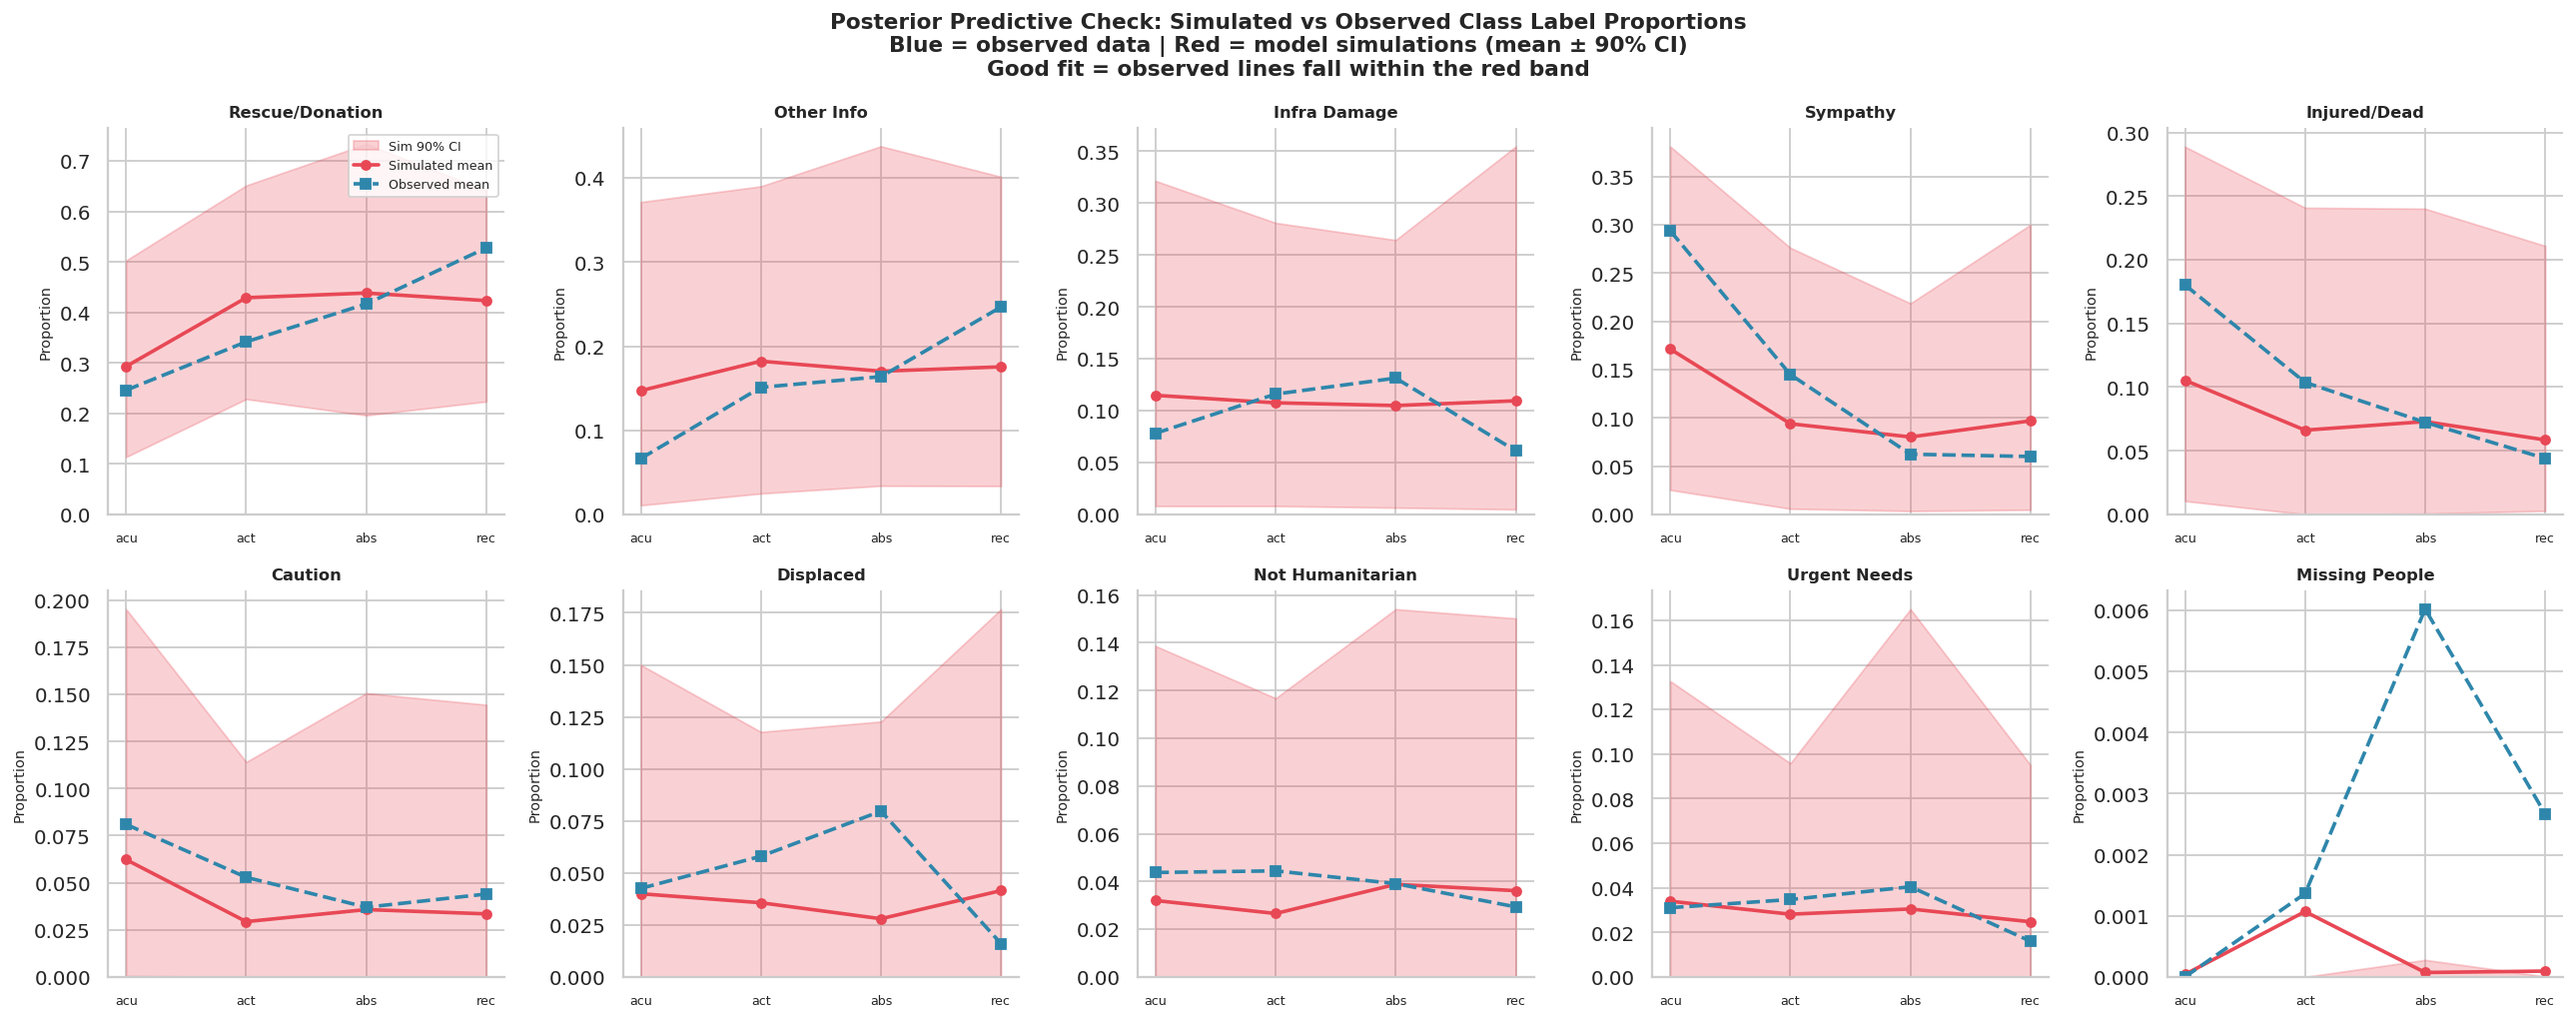

In [17]:
# Use mean intensity profile across all disasters
mean_int_profile = np.array([
    df[df["time_phase"] == p]["disaster_intensity"].mean()
    for p in PHASE_ORDER
])

N_SIM = 100
sim_states_all, sim_obs_all = model.simulate(mean_int_profile, n_trials=N_SIM)
sim_obs_arr = np.array(sim_obs_all)   # (N_SIM, T, D)

# Observed mean proportion per phase (across all disasters)
obs_mean = np.array([
    agg[agg["time_phase"] == p]["mean"].reindex(
        agg[agg["time_phase"] == p].set_index("class_label").index
    ).values
    if False else
    np.array([
        agg[(agg["time_phase"] == p) &
            (agg["class_label"] == l)]["mean"].values[0]
        if len(agg[(agg["time_phase"] == p) & (agg["class_label"] == l)]) > 0
        else 0.0
        for l in LABEL_ORDER
    ])
    for p in PHASE_ORDER
])   # (T, D)

T = min(len(mean_int_profile), obs_mean.shape[0])

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.ravel()

for d, label in enumerate(LABEL_ORDER):
    ax = axes[d]

    # Simulated: mean + 90% interval
    sim_d   = sim_obs_arr[:, :T, d]   # (N_SIM, T)
    sim_mean = sim_d.mean(axis=0)
    sim_lo   = np.percentile(sim_d,  5, axis=0)
    sim_hi   = np.percentile(sim_d, 95, axis=0)

    x = np.arange(T)
    ax.fill_between(x, sim_lo, sim_hi, alpha=0.25, color="#E84855", label="Sim 90% CI")
    ax.plot(x, sim_mean, "o-", color="#E84855", linewidth=2,
            markersize=5, label="Simulated mean")
    ax.plot(x, obs_mean[:T, d], "s--", color="#2E86AB", linewidth=2,
            markersize=5, label="Observed mean")

    ax.set_title(SHORT[label], fontsize=9, fontweight="bold")
    ax.set_xticks(range(T))
    ax.set_xticklabels([p[:3] for p in PHASE_ORDER[:T]], fontsize=7)
    ax.set_ylabel("Proportion", fontsize=8)
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if d == 0:
        ax.legend(fontsize=7, loc="upper right")

plt.suptitle(
    "Posterior Predictive Check: Simulated vs Observed Class Label Proportions\n"
    "Blue = observed data | Red = model simulations (mean ± 90% CI)\n"
    "Good fit = observed lines fall within the red band",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig8_posterior_predictive.png", dpi=130, bbox_inches="tight")
plt.show()

## Individual Antecedent Models (Per-Disaster Fit)

We fit a **separate IOHMM for each individual disaster** and compare log-likelihoods,
AIC, and BIC. This tells us:

1. Which disasters are **well-explained** by the model (high log-lik relative to length)
2. Which disasters are **outliers** — their behavioral trajectory doesn't fit the
   general pattern learned from all disasters
3. Whether the **combined model** generalises better than fitting each disaster alone

In [18]:
print("Fitting individual models per disaster (K=2 and K=3)...\n")
ind_results = []
n_obs_total = sum(len(s) for s in sequences)

for dis, seq, intv in zip(disaster_names, sequences, intensities):
    best = {"ll": -np.inf}
    for K in [2, 3]:
        m = IOHMM(n_states=K, n_obs=N_LABELS, random_state=42)
        m.fit([seq], [intv], n_restarts=5, verbose=False)
        if m.log_lik_ > best["ll"]:
            best = {"ll": m.log_lik_, "K": K,
                    "AIC": m.aic(), "BIC": m.bic(len(seq))}
    ind_results.append({
        "Disaster":  dis.replace("_", " ").title(),
        "Best K":    best["K"],
        "Log-Lik":   round(best["ll"], 2),
        "AIC":       round(best["AIC"], 2),
        "BIC":       round(best["BIC"], 2),
    })
    print(f"  {dis:<42s} K={best['K']}  LL={best['ll']:7.2f}  "
          f"AIC={best['AIC']:7.2f}  BIC={best['BIC']:7.2f}")

ind_df = pd.DataFrame(ind_results)
print("\nIndividual model summary:")
print(ind_df.to_string(index=False))

Fitting individual models per disaster (K=2 and K=3)...

  canada_wildfires_2016                      K=2  LL=  -3.33  AIC=  66.67  BIC=  27.46
  cyclone_idai_2019                          K=3  LL=  -4.73  AIC= 111.46  BIC=  65.49
  hurricane_harvey_2017                      K=2  LL=  -3.85  AIC=  67.70  BIC=  28.50
  hurricane_irma_2017                        K=2  LL=  -3.92  AIC=  67.84  BIC=  28.64
  hurricane_maria_2017                       K=3  LL=  -3.65  AIC= 109.31  BIC=  42.66
  italy_earthquake_aug_2016                  K=3  LL=  -2.77  AIC= 107.54  BIC=  40.89
  kaikoura_earthquake_2016                   K=2  LL=  -3.74  AIC=  67.48  BIC=  28.27
  puebla_mexico_earthquake_2017              K=2  LL=  -4.45  AIC=  68.89  BIC=  41.85
  srilanka_floods_2017                       K=3  LL=  -4.18  AIC= 110.35  BIC=  64.38

Individual model summary:
                     Disaster  Best K  Log-Lik    AIC   BIC
        Canada Wildfires 2016       2    -3.33  66.67 27.46
            C

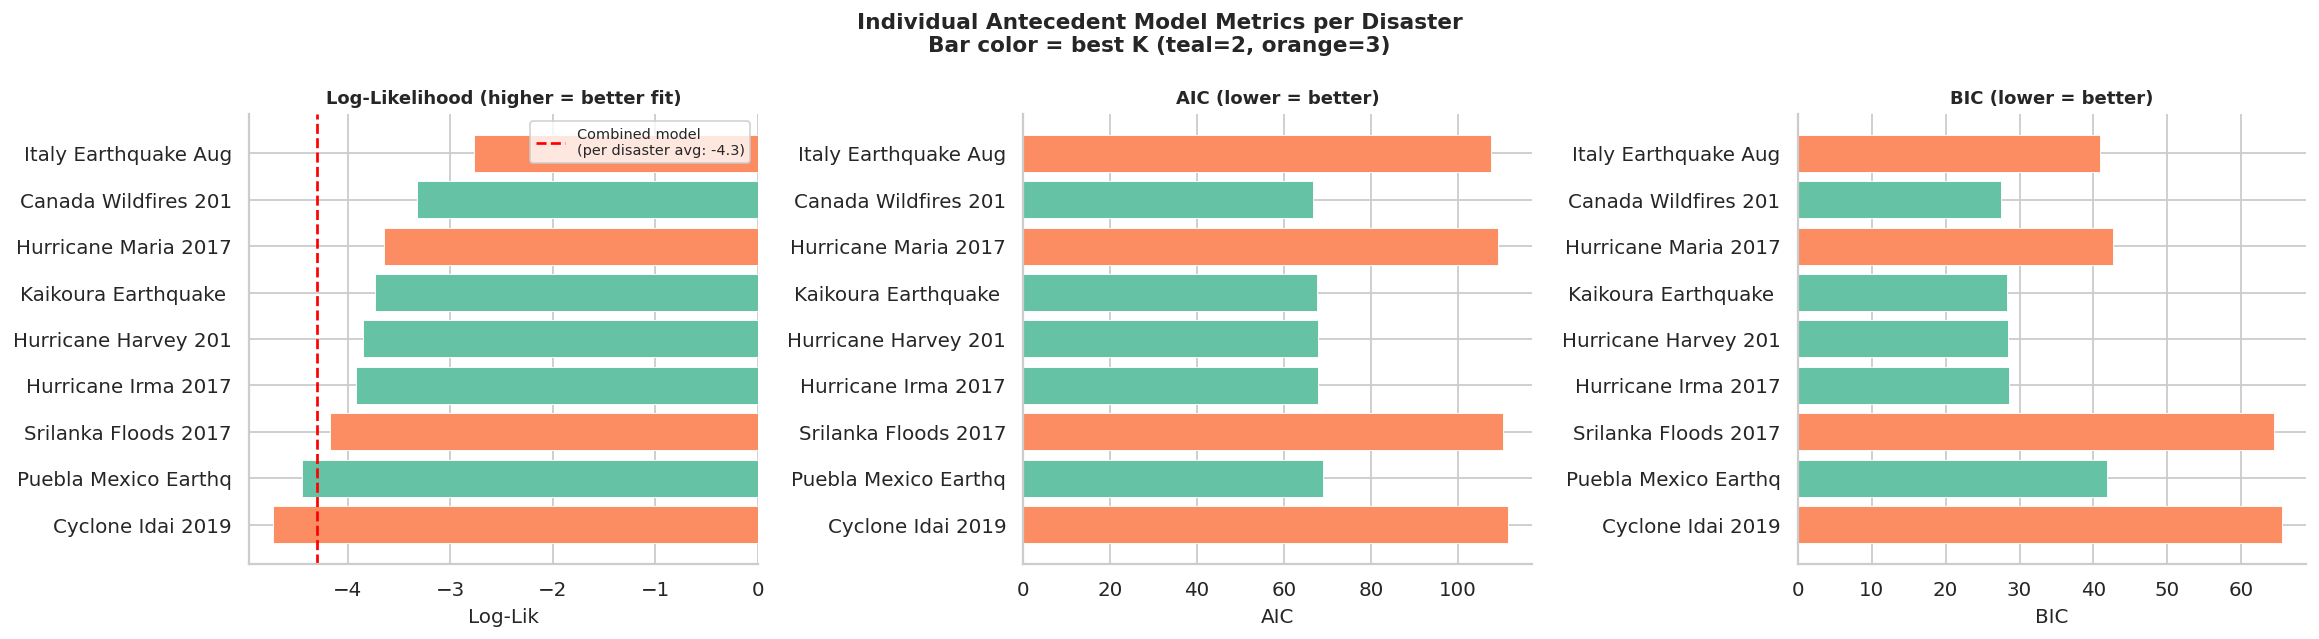

In [19]:
ind_sorted = ind_df.sort_values("Log-Lik")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = [sns.color_palette("Set2", n_colors=best_K)[r["Best K"]-2]
              for _, r in ind_sorted.iterrows()]

for ax, metric, title, best_is in zip(
        axes,
        ["Log-Lik", "AIC", "BIC"],
        ["Log-Likelihood (higher = better fit)",
         "AIC (lower = better)",
         "BIC (lower = better)"],
        ["high", "low", "low"]):
    vals = ind_sorted[metric].values
    dis_labels = [d[:20] for d in ind_sorted["Disaster"]]
    bars = ax.barh(dis_labels, vals, color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if metric == "Log-Lik":
        per_dis_ll = model.log_lik_ / len(disaster_names)
        ax.axvline(per_dis_ll, color="red", linestyle="--", linewidth=1.5,
                   label=f"Combined model\n(per disaster avg: {per_dis_ll:.1f})")
        ax.legend(fontsize=8)

plt.suptitle("Individual Antecedent Model Metrics per Disaster\n"
             "Bar color = best K (teal=2, orange=3)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig9_individual_models.png", dpi=150, bbox_inches="tight")
plt.show()

## Cross-Validation (Leave-One-Disaster-Out)

**Leave-one-disaster-out cross-validation**: train on 10 disasters, evaluate on
the held-out disaster. Repeat for each disaster. The mean held-out log-likelihood
is our **generalization metric**.
Cross-validation answers the real question: **does the model generalize?**
A model that generalizes well has learned *genuine* structure about how disaster
discourse evolves, not just memorized the 11 specific trajectories.

In [20]:
print("Leave-one-disaster-out cross-validation...\n")
cv_lls = []

for i, held_dis in enumerate(disaster_names):
    train_seqs = [s for j, s in enumerate(sequences)   if j != i]
    train_ints = [v for j, v in enumerate(intensities)  if j != i]
    test_seq   = sequences[i]
    test_int   = intensities[i]

    cv_model = IOHMM(n_states=best_K, n_obs=N_LABELS, random_state=i)
    cv_model.fit(train_seqs, train_ints, n_restarts=5, verbose=False)

    ll_held, _ = cv_model._forward(cv_model.params_, test_seq, test_int)
    cv_lls.append(ll_held)
    print(f"  Held out: {held_dis:<42s}  log-lik = {ll_held:.3f}")

mean_cv_ll = np.mean(cv_lls)
print(f"\n  Mean CV log-likelihood : {mean_cv_ll:.3f}")
print(f"  Training log-likelihood: {model.log_lik_:.3f}")
print(f"  Overfitting gap        : {model.log_lik_ - mean_cv_ll*len(disaster_names):.3f}")

Leave-one-disaster-out cross-validation...

  Held out: canada_wildfires_2016                       log-lik = -4.259
  Held out: cyclone_idai_2019                           log-lik = -5.394
  Held out: hurricane_harvey_2017                       log-lik = -4.009
  Held out: hurricane_irma_2017                         log-lik = -4.435
  Held out: hurricane_maria_2017                        log-lik = -3.985
  Held out: italy_earthquake_aug_2016                   log-lik = -3.784
  Held out: kaikoura_earthquake_2016                    log-lik = -4.390
  Held out: puebla_mexico_earthquake_2017               log-lik = -4.972
  Held out: srilanka_floods_2017                        log-lik = -4.997

  Mean CV log-likelihood : -4.469
  Training log-likelihood: -38.718
  Overfitting gap        : 1.507


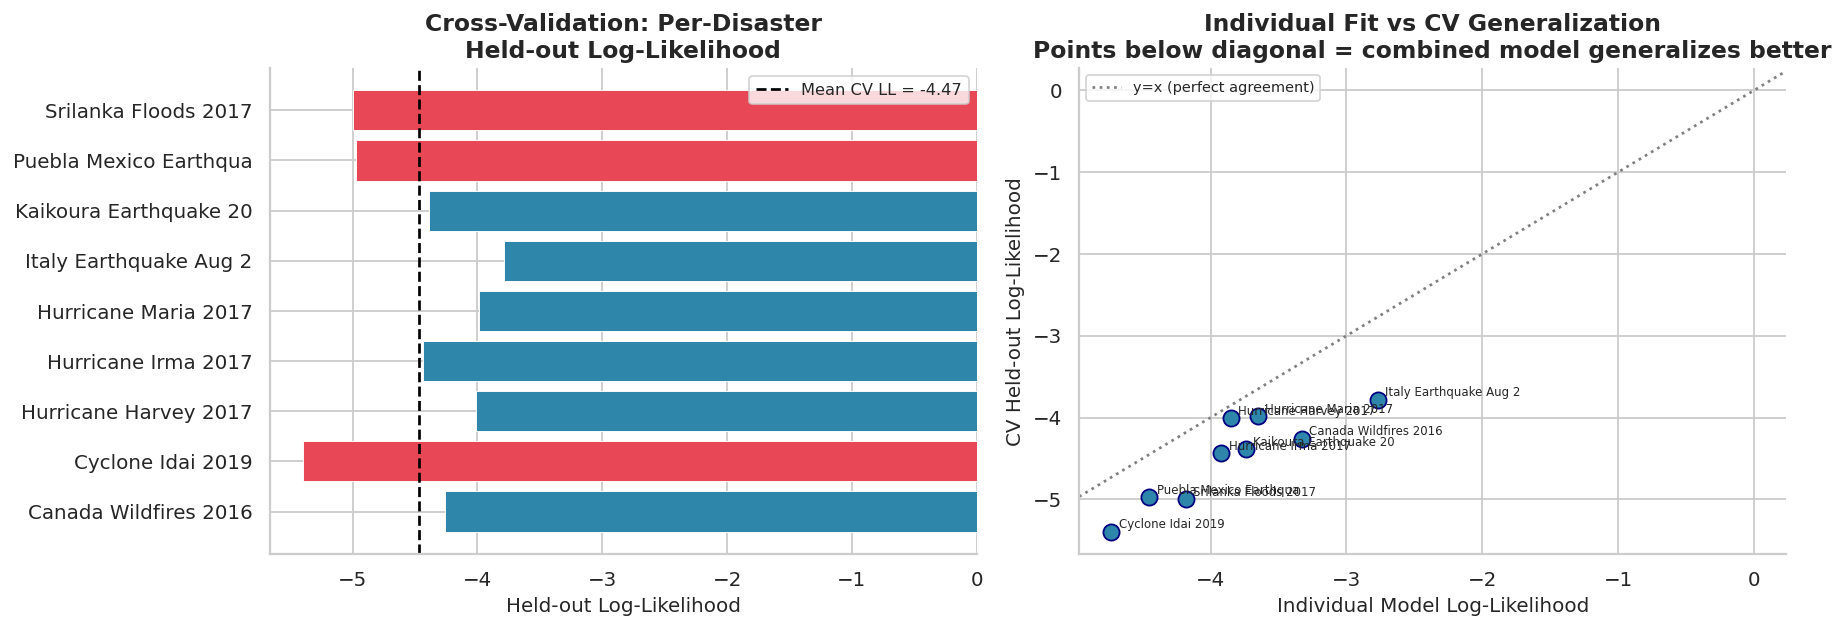

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
short_dis = [d.replace("_", " ").title()[:22] for d in disaster_names]
colors_cv = ["#2E86AB" if ll > mean_cv_ll else "#E84855" for ll in cv_lls]
axes[0].barh(short_dis, cv_lls, color=colors_cv, edgecolor="white", linewidth=0.5)
axes[0].axvline(mean_cv_ll, color="black", linestyle="--", linewidth=1.5,
                label=f"Mean CV LL = {mean_cv_ll:.2f}")
axes[0].set_xlabel("Held-out Log-Likelihood")
axes[0].set_title("Cross-Validation: Per-Disaster\nHeld-out Log-Likelihood",
                   fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
ind_lls_ordered = [ind_df[ind_df["Disaster"] == d.replace("_", " ").title()]["Log-Lik"].values[0]
                   if d.replace("_", " ").title() in ind_df["Disaster"].values else np.nan
                   for d in disaster_names]
axes[1].scatter(ind_lls_ordered, cv_lls, s=80, color="#2E86AB", edgecolors="navy", zorder=3)
for x, y, name in zip(ind_lls_ordered, cv_lls, short_dis):
    if not np.isnan(x):
        axes[1].annotate(name, (x, y), fontsize=6.5, xytext=(4, 2),
                          textcoords="offset points")
axes[1].axline((0, 0), slope=1, color="gray", linestyle=":", label="y=x (perfect agreement)")
axes[1].set_xlabel("Individual Model Log-Likelihood")
axes[1].set_ylabel("CV Held-out Log-Likelihood")
axes[1].set_title("Individual Fit vs CV Generalization\n"
                   "Points below diagonal = combined model generalizes better",
                   fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig10_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()